# Fraud Detection using Machine Learning

This notebook detects fraudulent transactions in a dataset of about 6.3 million
financial transactions. Only around 0.13% of them are fraud, so the data is very imbalanced
and accuracy is not a useful metric here. The main metrics are recall, precision and PR-AUC.

Steps:
1. Load the data and do some EDA
2. Create a smaller dataset for modeling and split it into train / validation / test
3. Compare a few models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost)
4. Tune XGBoost with Optuna
5. Choose a classification threshold
6. Test the final model on a test set with the real fraud rate
7. Use SHAP to see which features the model relies on

## Loading the data

The dataset is loaded from Google Drive.

In [65]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

data_folder = "/content/drive/MyDrive/fraud detection project/data"

print(os.listdir(data_folder))

['AIML Dataset.csv']


In [4]:
import os

file_path = "/content/drive/MyDrive/fraud detection project/data/AIML Dataset.csv"

size_mb = os.path.getsize(file_path) / (1024 ** 2)

print(f"File size: {size_mb:.2f} MB")

File size: 470.67 MB


In [5]:
import pandas as pd

df_sample = pd.read_csv(
    file_path,
    nrows=10000
)

print("Shape:", df_sample.shape)
print("\nColumns:")
print(df_sample.columns.tolist())

print("\nFirst 5 rows:")
display(df_sample.head())

Shape: (10000, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## EDA

First a 10,000 row sample is used to understand the columns, then the class balance is checked on the full file.

In [6]:
print("DATA TYPES")
print(df_sample.dtypes)

print("\nMISSING VALUES")
print(df_sample.isnull().sum())

print("\nTARGET DISTRIBUTION")
print(df_sample["isFraud"].value_counts())

print("\nTARGET PERCENTAGE")
print(df_sample["isFraud"].value_counts(normalize=True) * 100)

print("\nTRANSACTION TYPES")
print(df_sample["type"].value_counts())

print("\nDUPLICATE ROWS")
print(df_sample.duplicated().sum())

DATA TYPES
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

MISSING VALUES
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

TARGET DISTRIBUTION
isFraud
0    9932
1      68
Name: count, dtype: int64

TARGET PERCENTAGE
isFraud
0    99.32
1     0.68
Name: proportion, dtype: float64

TRANSACTION TYPES
type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64

DUPLICATE ROWS
0


In [7]:
import pandas as pd

target_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, usecols=["isFraud"], chunksize=500000):
    target_counts = target_counts.add(
        chunk["isFraud"].value_counts(),
        fill_value=0
    )

target_counts = target_counts.astype(int)

print("Full Dataset Target Distribution:")
print(target_counts)

print("\nPercentage:")
print((target_counts / target_counts.sum() * 100).round(4))

Full Dataset Target Distribution:
isFraud
0    6354407
1       8213
dtype: int64

Percentage:
isFraud
0    99.8709
1     0.1291
dtype: float64


### Fraud by transaction type and amount

In [8]:
print("Fraud by transaction type:")
print(
    df_sample.groupby("type")["isFraud"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

print("\nFraud transaction amounts:")
print(
    df_sample[df_sample["isFraud"] == 1]["amount"]
    .describe()
)

print("\nNormal transaction amounts:")
print(
    df_sample[df_sample["isFraud"] == 0]["amount"]
    .describe()
)

Fraud by transaction type:
          count  sum      mean
type                          
TRANSFER    921   33  0.035831
CASH_OUT   1321   35  0.026495
CASH_IN    1949    0  0.000000
DEBIT       344    0  0.000000
PAYMENT    5465    0  0.000000

Fraud transaction amounts:
count    6.800000e+01
mean     5.334636e+05
std      1.753539e+06
min      1.810000e+02
25%      1.494984e+04
50%      2.864476e+04
75%      1.815618e+05
max      1.000000e+07
Name: amount, dtype: float64

Normal transaction amounts:
count    9.932000e+03
mean     1.006032e+05
std      2.222295e+05
min      2.390000e+00
25%      4.372755e+03
50%      1.274065e+04
75%      1.140599e+05
max      3.776389e+06
Name: amount, dtype: float64


### Balance features

Checking if the balance changes look different for fraud and normal transactions.

In [9]:
df_sample["orig_balance_change"] = (
    df_sample["oldbalanceOrg"] - df_sample["newbalanceOrig"]
)

df_sample["dest_balance_change"] = (
    df_sample["newbalanceDest"] - df_sample["oldbalanceDest"]
)

df_sample["orig_error"] = (
    df_sample["amount"] - df_sample["orig_balance_change"]
)

df_sample["dest_error"] = (
    df_sample["amount"] - df_sample["dest_balance_change"]
)

print("Fraud transactions:")
display(
    df_sample[df_sample["isFraud"] == 1][
        [
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "orig_balance_change",
            "dest_balance_change",
            "orig_error",
            "dest_error"
        ]
    ].head(10)
)

print("\nNormal transactions:")
display(
    df_sample[df_sample["isFraud"] == 0][
        [
            "amount",
            "oldbalanceOrg",
            "newbalanceOrig",
            "oldbalanceDest",
            "newbalanceDest",
            "orig_balance_change",
            "dest_balance_change",
            "orig_error",
            "dest_error"
        ]
    ].head(10)
)

Fraud transactions:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_error,dest_error
2,181.00,181.00,0.0,0.0,0.00,181.00,0.00,0.00,181.00
3,181.00,181.00,0.0,21182.0,0.00,181.00,-21182.00,0.00,21363.00
251,2806.00,2806.00,0.0,0.0,0.00,2806.00,0.00,0.00,2806.00
252,2806.00,2806.00,0.0,26202.0,0.00,2806.00,-26202.00,0.00,29008.00
680,20128.00,20128.00,0.0,0.0,0.00,20128.00,0.00,0.00,20128.00
681,20128.00,20128.00,0.0,6268.0,12145.85,20128.00,5877.85,0.00,14250.15
724,416001.33,0.00,0.0,102.0,9291619.62,0.00,9291517.62,416001.33,-8875516.29
969,1277212.77,1277212.77,0.0,0.0,0.00,1277212.77,0.00,0.00,1277212.77
970,1277212.77,1277212.77,0.0,0.0,2444985.19,1277212.77,2444985.19,0.00,-1167772.42
1115,35063.63,35063.63,0.0,0.0,0.00,35063.63,0.00,0.00,35063.63



Normal transactions:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_error,dest_error
0,9839.64,170136.00,160296.36,0.0,0.00,9839.64,0.00,-1.455192e-11,9839.64
1,1864.28,21249.00,19384.72,0.0,0.00,1864.28,0.00,1.136868e-12,1864.28
4,11668.14,41554.00,29885.86,0.0,0.00,11668.14,0.00,0.000000e+00,11668.14
5,7817.71,53860.00,46042.29,0.0,0.00,7817.71,0.00,9.094947e-13,7817.71
6,7107.77,183195.00,176087.23,0.0,0.00,7107.77,0.00,1.091394e-11,7107.77
7,7861.64,176087.23,168225.59,0.0,0.00,7861.64,0.00,-1.364242e-11,7861.64
8,4024.36,2671.00,0.00,0.0,0.00,2671.00,0.00,1.353360e+03,4024.36
9,5337.77,41720.00,36382.23,41898.0,40348.79,5337.77,-1549.21,3.637979e-12,6886.98
10,9644.94,4465.00,0.00,10845.0,157982.12,4465.00,147137.12,5.179940e+03,-137492.18
11,3099.97,20771.00,17671.03,0.0,0.00,3099.97,0.00,-1.364242e-12,3099.97


In [10]:
features_to_compare = [
    "amount",
    "orig_balance_change",
    "dest_balance_change",
    "orig_error",
    "dest_error"
]

comparison = df_sample.groupby("isFraud")[features_to_compare].agg(
    ["mean", "median", "std"]
)

display(comparison)

amount                          orig_balance_change            \
                  mean     median           std                mean    median   
isFraud                                                                         
0        100603.239233  12740.655  2.222295e+05       -25084.755080    526.36   
1        533463.638676  28644.760  1.753539e+06       525458.566765  26372.18   

                      dest_balance_change                          orig_error  \
                  std                mean median           std           mean   
isFraud                                                                         
0        9.982011e+04       160394.863264    0.0  9.985023e+05  125687.994312   
1        1.755180e+06       445062.667941    0.0  1.702130e+06    8005.071912   

                                    dest_error                           
           median            std          mean     median           std  
isFraud                                                                  
0        5624.455  261016.525681 -59791.624031   6579.690  9.489570e+05  
1           0.000   52571.437675  88400.970735  14599.995  1.706815e+06

In [11]:
print("Median absolute errors:")

error_comparison = df_sample.groupby("isFraud")[
    ["orig_error", "dest_error"]
].apply(lambda x: x.abs().median())

display(error_comparison)

Median absolute errors:


,orig_error,dest_error
isFraud,,
0,5624.455,10808.355
1,0.000,23221.175


### Fraud rate by transaction type (full dataset)

In [12]:
type_fraud = pd.DataFrame()

for chunk in pd.read_csv(
    file_path,
    usecols=["type", "isFraud"],
    chunksize=500000
):
    temp = chunk.groupby("type")["isFraud"].agg(["count", "sum"])
    type_fraud = pd.concat([type_fraud, temp])

type_fraud = type_fraud.groupby(level=0).sum()

type_fraud["fraud_rate"] = (
    type_fraud["sum"] / type_fraud["count"] * 100
)

type_fraud = type_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

display(type_fraud)

,count,sum,fraud_rate
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


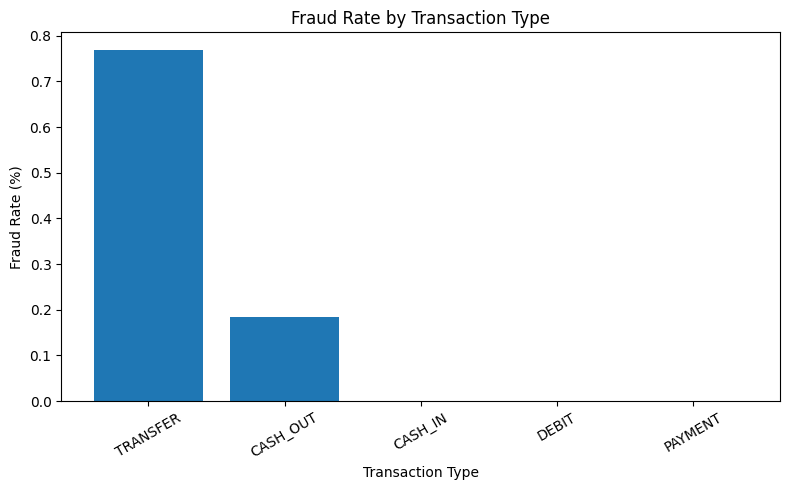

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    type_fraud.index,
    type_fraud["fraud_rate"]
)

plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Type")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

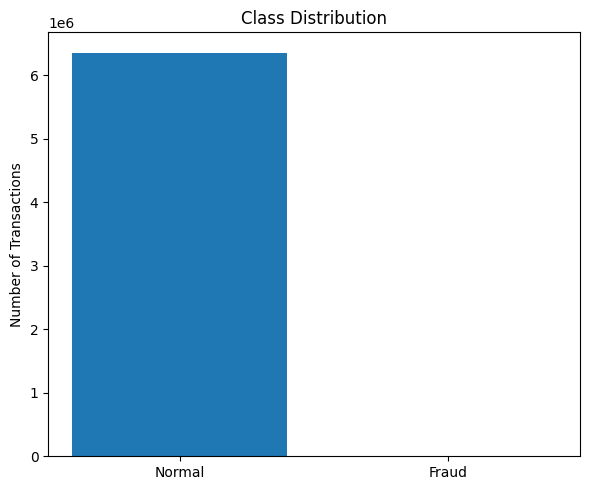

In [14]:
plt.figure(figsize=(6, 5))

plt.bar(
    ["Normal", "Fraud"],
    [
        target_counts[0],
        target_counts[1]
    ]
)

plt.ylabel("Number of Transactions")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()

### Transaction amount distribution

The amount is very right-skewed, so log(1 + amount) is also plotted.

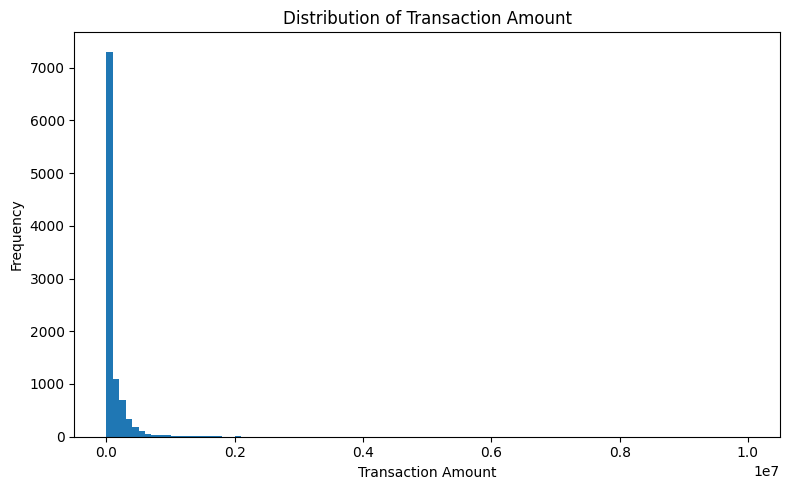

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_sample["amount"],
    bins=100
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")

plt.tight_layout()
plt.show()

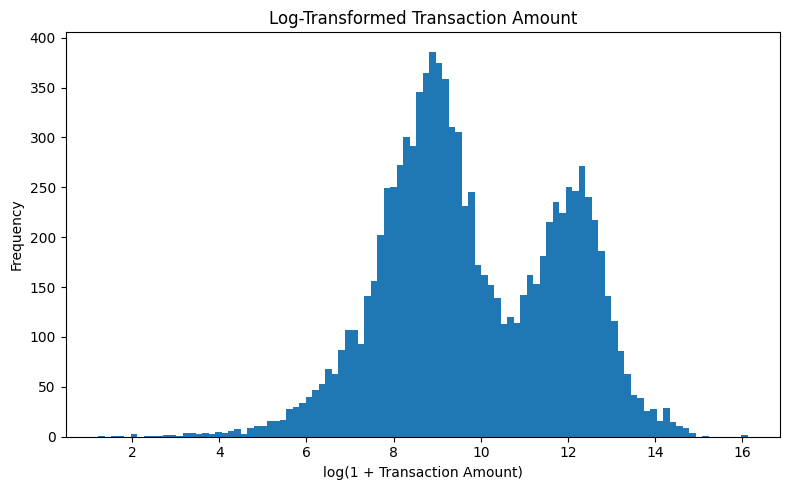

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df_sample["amount"]),
    bins=100
)

plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Transaction Amount")

plt.tight_layout()
plt.show()

## Creating the modeling dataset

The full dataset is too big to train on, so all fraud cases are kept and 200,000 normal transactions are sampled.

In [17]:
import pandas as pd
import numpy as np

# Columns we actually need
usecols = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

fraud_parts = []
normal_parts = []

normal_needed = 200000

for chunk in pd.read_csv(
    file_path,
    usecols=usecols,
    chunksize=500000
):
    # Keep ALL fraud transactions
    fraud = chunk[chunk["isFraud"] == 1]
    fraud_parts.append(fraud)

    # Keep normal transactions until we have enough
    if normal_needed > 0:
        normal = chunk[chunk["isFraud"] == 0]

        take = min(len(normal), normal_needed)

        normal_parts.append(
            normal.sample(
                n=take,
                random_state=42
            )
        )

        normal_needed -= take

    if normal_needed <= 0:
        # We already have enough normal transactions,
        # but continue reading to collect all fraud cases.
        continue

# Combine everything
fraud_df = pd.concat(fraud_parts, ignore_index=True)
normal_df = pd.concat(normal_parts, ignore_index=True)

df = pd.concat(
    [fraud_df, normal_df],
    ignore_index=True
)

# Shuffle the resulting dataset
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Final shape:", df.shape)

print("\nClass distribution:")
print(df["isFraud"].value_counts())

print("\nClass percentage:")
print(
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

Final shape: (208213, 9)

Class distribution:
isFraud
0    200000
1      8213
Name: count, dtype: int64

Class percentage:
isFraud
0    96.055
1     3.945
Name: proportion, dtype: float64


In [18]:
# Feature engineering

df["orig_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

df["orig_error"] = (
    df["amount"] - df["orig_balance_change"]
)

df["dest_error"] = (
    df["amount"] - df["dest_balance_change"]
)

# Log transformation for the highly skewed transaction amount
df["log_amount"] = np.log1p(df["amount"])

print("New shape:", df.shape)

print("\nNew columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

New shape: (208213, 14)

New columns:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'dest_error', 'log_amount']

Missing values:
0


In [19]:
# Separate features and target

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (208213, 13)
y shape: (208213,)

Target distribution:
isFraud
0    200000
1      8213
Name: count, dtype: int64


The first version only took normal transactions from the start of the file. Here the sampling is done
from every chunk instead, so the normal transactions come from the whole dataset.

In [22]:
import pandas as pd
import numpy as np

usecols = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

fraud_parts = []
normal_parts = []

TOTAL_NORMAL = 6354407
TARGET_NORMAL = 200000

# Exact sampling fraction
fraction = TARGET_NORMAL / TOTAL_NORMAL

rng = np.random.default_rng(42)

for chunk in pd.read_csv(
    file_path,
    usecols=usecols,
    chunksize=500000
):

    # Keep ALL fraud transactions
    fraud = chunk[chunk["isFraud"] == 1]

    if len(fraud) > 0:
        fraud_parts.append(fraud)

    # Normal transactions
    normal = chunk[chunk["isFraud"] == 0]

    # Take slightly more than required proportionally
    n_to_sample = int(np.ceil(len(normal) * fraction)) + 2

    n_to_sample = min(n_to_sample, len(normal))

    sampled_normal = normal.sample(
        n=n_to_sample,
        random_state=42
    )

    normal_parts.append(sampled_normal)


# Combine everything
fraud_df = pd.concat(
    fraud_parts,
    ignore_index=True
)

normal_df = pd.concat(
    normal_parts,
    ignore_index=True
)

print("Normal rows collected:", len(normal_df))
print("Fraud rows collected:", len(fraud_df))


# Now we definitely have >= 200,000 normal rows
normal_df = normal_df.sample(
    n=TARGET_NORMAL,
    random_state=42
)


# Combine
df = pd.concat(
    [normal_df, fraud_df],
    ignore_index=True
)


# Shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


print("\nFINAL DATASET")
print("Shape:", df.shape)

print("\nClass distribution:")
print(df["isFraud"].value_counts())

print("\nClass percentage:")
print(
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

Normal rows collected: 200033
Fraud rows collected: 8213

FINAL DATASET
Shape: (208213, 9)

Class distribution:
isFraud
0    200000
1      8213
Name: count, dtype: int64

Class percentage:
isFraud
0    96.055
1     3.945
Name: proportion, dtype: float64


In [24]:
# Feature engineering

df["orig_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

df["orig_error"] = (
    df["amount"] - df["orig_balance_change"]
)

df["dest_error"] = (
    df["amount"] - df["dest_balance_change"]
)

df["log_amount"] = np.log1p(df["amount"])

print("Final shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:", df.isnull().sum().sum())

Final shape: (208213, 14)

Columns:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'dest_error', 'log_amount']

Missing values: 0


## Train / validation / test split

70% train, 15% validation, 15% test, stratified so each part has the same fraud rate.

In [25]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining fraud percentage:",
      round(y_train.mean() * 100, 3), "%")

print("Validation fraud percentage:",
      round(y_val.mean() * 100, 3), "%")

print("Test fraud percentage:",
      round(y_test.mean() * 100, 3), "%")

Training set: (145749, 13)
Validation set: (31232, 13)
Test set: (31232, 13)

Training fraud percentage: 3.944 %
Validation fraud percentage: 3.945 %
Test fraud percentage: 3.945 %


In [26]:
print("TRAIN")
print(y_train.value_counts())
print()

print("VALIDATION")
print(y_val.value_counts())
print()

print("TEST")
print(y_test.value_counts())

TRAIN
isFraud
0    140000
1      5749
Name: count, dtype: int64

VALIDATION
isFraud
0    30000
1     1232
Name: count, dtype: int64

TEST
isFraud
0    30000
1     1232
Name: count, dtype: int64


## Preprocessing

Dropping the account name columns, then scaling the numerical features and one-hot encoding `type`.

In [27]:
# Drop identifier columns
drop_cols = ["nameOrig", "nameDest"]

X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_val = X_val.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

# Categorical and numerical columns
categorical_features = ["type"]

numerical_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "orig_balance_change",
    "dest_balance_change",
    "orig_error",
    "dest_error",
    "log_amount"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTraining shape:", X_train.shape)

Categorical features:
['type']

Numerical features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'dest_error', 'log_amount']

Training shape: (145749, 13)


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## Models

### Logistic Regression

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Create pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [30]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_val_pred = logistic_model.predict(X_val)

# Probability of fraud
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

# Classification report
print("CLASSIFICATION REPORT")
print(classification_report(y_val, y_val_pred))

# Confusion matrix
print("\nCONFUSION MATRIX")
print(confusion_matrix(y_val, y_val_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_val_prob)

# PR-AUC
pr_auc = average_precision_score(y_val, y_val_prob)

print("\nROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     30000
           1       0.45      0.98      0.62      1232

    accuracy                           0.95     31232
   macro avg       0.73      0.96      0.80     31232
weighted avg       0.98      0.95      0.96     31232


CONFUSION MATRIX
[[28542  1458]
 [   27  1205]]

ROC-AUC: 0.9933
PR-AUC: 0.908


### Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=12,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [32]:
y_val_pred_dt = decision_tree_model.predict(X_val)
y_val_prob_dt = decision_tree_model.predict_proba(X_val)[:, 1]

print("DECISION TREE")
print(classification_report(y_val, y_val_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_dt))

print(
    "\nROC-AUC:",
    round(roc_auc_score(y_val, y_val_prob_dt), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, y_val_prob_dt), 4)
)

DECISION TREE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30000
           1       1.00      1.00      1.00      1232

    accuracy                           1.00     31232
   macro avg       1.00      1.00      1.00     31232
weighted avg       1.00      1.00      1.00     31232


Confusion Matrix:
[[29997     3]
 [    3  1229]]

ROC-AUC: 0.9987
PR-AUC: 0.996


In [33]:
# Get transformed feature names
feature_names = decision_tree_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importances = decision_tree_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance.head(15))

,feature,importance
7,num__orig_balance_change,6.529679e-01
3,num__newbalanceOrig,1.618036e-01
9,num__orig_error,1.518078e-01
1,num__amount,2.282024e-02
6,num__isFlaggedFraud,3.094574e-03
2,num__oldbalanceOrg,2.096419e-03
8,num__dest_balance_change,1.428017e-03
5,num__newbalanceDest,1.379880e-03
4,num__oldbalanceDest,9.482464e-04
11,num__log_amount,7.425174e-04


The decision tree gets almost perfect scores, and its top features are the engineered balance features.
These basically give away the answer, so from here on only the original columns are used.

In [34]:
# Features we'll exclude from the independent fraud model
engineered_features = [
    "orig_balance_change",
    "dest_balance_change",
    "orig_error",
    "dest_error",
    "log_amount"
]

# Remove existing fraud flag as well
excluded_features = [
    "isFlaggedFraud"
]

# Create a clean version of the feature sets
X_train_clean = X_train.drop(
    columns=excluded_features,
    errors="ignore"
)

X_val_clean = X_val.drop(
    columns=excluded_features,
    errors="ignore"
)

X_test_clean = X_test.drop(
    columns=excluded_features,
    errors="ignore"
)

print("Features:")
print(X_train_clean.columns.tolist())

print("\nNumber of features:", X_train_clean.shape[1])

Features:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'dest_error', 'log_amount']

Number of features: 12


In [35]:
# Original features only
original_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

X_train_original = X_train[original_features]
X_val_original = X_val[original_features]
X_test_original = X_test[original_features]

print("Original feature set:")
print(X_train_original.columns.tolist())

print("\nNumber of features:", X_train_original.shape[1])

Original feature set:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

Number of features: 7


In [36]:
categorical_original = ["type"]

numerical_original = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

preprocessor_original = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_original
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_original
        )
    ]
)

print("Original-feature preprocessor ready.")

Original-feature preprocessor ready.


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_original = Pipeline(
    steps=[
        ("preprocessor", preprocessor_original),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=12,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

dt_original.fit(X_train_original, y_train)

y_pred_original = dt_original.predict(X_val_original)
y_prob_original = dt_original.predict_proba(X_val_original)[:, 1]

print("DECISION TREE — ORIGINAL FEATURES")
print(classification_report(y_val, y_pred_original))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_original))

print(
    "\nROC-AUC:",
    round(roc_auc_score(y_val, y_prob_original), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, y_prob_original), 4)
)

DECISION TREE — ORIGINAL FEATURES
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     30000
           1       0.88      0.98      0.93      1232

    accuracy                           0.99     31232
   macro avg       0.94      0.99      0.96     31232
weighted avg       0.99      0.99      0.99     31232


Confusion Matrix:
[[29835   165]
 [   27  1205]]

ROC-AUC: 0.9884
PR-AUC: 0.958


### Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_original = Pipeline(
    steps=[
        ("preprocessor", preprocessor_original),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

rf_original.fit(X_train_original, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [39]:
y_pred_rf = rf_original.predict(X_val_original)
y_prob_rf = rf_original.predict_proba(X_val_original)[:, 1]

print("RANDOM FOREST — ORIGINAL FEATURES")
print(classification_report(y_val, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))

print(
    "\nROC-AUC:",
    round(roc_auc_score(y_val, y_prob_rf), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, y_prob_rf), 4)
)

RANDOM FOREST — ORIGINAL FEATURES
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     30000
           1       0.83      0.98      0.90      1232

    accuracy                           0.99     31232
   macro avg       0.92      0.99      0.95     31232
weighted avg       0.99      0.99      0.99     31232


Confusion Matrix:
[[29756   244]
 [   20  1212]]

ROC-AUC: 0.9986
PR-AUC: 0.9889


### Gradient Boosting

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb_original = Pipeline(
    steps=[
        ("preprocessor", preprocessor_original),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_original.fit(X_train_original, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [41]:
y_pred_gb = gb_original.predict(X_val_original)
y_prob_gb = gb_original.predict_proba(X_val_original)[:, 1]

print("GRADIENT BOOSTING — ORIGINAL FEATURES")
print(classification_report(y_val, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_gb))

print(
    "\nROC-AUC:",
    round(roc_auc_score(y_val, y_prob_gb), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, y_prob_gb), 4)
)

GRADIENT BOOSTING — ORIGINAL FEATURES
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30000
           1       0.97      0.89      0.93      1232

    accuracy                           0.99     31232
   macro avg       0.98      0.94      0.96     31232
weighted avg       0.99      0.99      0.99     31232


Confusion Matrix:
[[29962    38]
 [  134  1098]]

ROC-AUC: 0.9979
PR-AUC: 0.9822


### XGBoost

In [42]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [43]:
from xgboost import XGBClassifier

xgb_original = Pipeline(
    steps=[
        ("preprocessor", preprocessor_original),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

xgb_original.fit(X_train_original, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [44]:
y_pred_xgb = xgb_original.predict(X_val_original)
y_prob_xgb = xgb_original.predict_proba(X_val_original)[:, 1]

print("XGBOOST — ORIGINAL FEATURES")
print(classification_report(y_val, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_xgb))

print(
    "\nROC-AUC:",
    round(roc_auc_score(y_val, y_prob_xgb), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_val, y_prob_xgb), 4)
)

XGBOOST — ORIGINAL FEATURES
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30000
           1       0.98      0.97      0.97      1232

    accuracy                           1.00     31232
   macro avg       0.99      0.98      0.98     31232
weighted avg       1.00      1.00      1.00     31232


Confusion Matrix:
[[29970    30]
 [   43  1189]]

ROC-AUC: 0.9994
PR-AUC: 0.9961


### Comparing the models

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Precision": [
        0.45,
        0.88,
        0.83,
        0.97,
        0.98
    ],
    "Recall": [
        0.98,
        0.98,
        0.98,
        0.89,
        0.97
    ],
    "F1": [
        0.62,
        0.93,
        0.90,
        0.93,
        0.97
    ],
    "ROC_AUC": [
        0.9933,
        0.9884,
        0.9986,
        0.9979,
        0.9994
    ],
    "PR_AUC": [
        0.9080,
        0.9580,
        0.9889,
        0.9822,
        0.9961
    ]
})

display(results)

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.45,0.98,0.62,0.9933,0.9080
1,Decision Tree,0.88,0.98,0.93,0.9884,0.9580
2,Random Forest,0.83,0.98,0.90,0.9986,0.9889
3,Gradient Boosting,0.97,0.89,0.93,0.9979,0.9822
4,XGBoost,0.98,0.97,0.97,0.9994,0.9961


## Hyperparameter tuning with Optuna

XGBoost gave the best results, so it is tuned further with Optuna, which learns from
the previous trials instead of picking random parameter combinations.

15 trials, 3-fold cross-validation, and PR-AUC as the score (because of the class imbalance).

In [42]:
%pip install -q optuna

Note: you may need to restart the kernel to use updated packages.


In [43]:
import optuna
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "classifier__n_estimators": trial.suggest_int("n_estimators", 100, 399),
        "classifier__max_depth": trial.suggest_int("max_depth", 3, 9),
        "classifier__learning_rate": trial.suggest_float("learning_rate", 0.02, 0.20),
        "classifier__subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "classifier__colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "classifier__min_child_weight": trial.suggest_int("min_child_weight", 1, 9),
    }

    model = clone(xgb_original).set_params(**params)

    scores = cross_val_score(
        model,
        X_train_original,
        y_train,
        cv=3,
        scoring="average_precision"
    )
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting XGBoost hyperparameter tuning with Optuna...")
study.optimize(objective, n_trials=15)

print("\nBest parameters:")
print(study.best_params)

print("\nBest CV PR-AUC:")
print(round(study.best_value, 4))

Starting XGBoost hyperparameter tuning with Optuna...



Best parameters:
{'n_estimators': 236, 'max_depth': 8, 'learning_rate': 0.05594128078850476, 'subsample': 0.8542703315240835, 'colsample_bytree': 0.8777243706586128, 'min_child_weight': 1}

Best CV PR-AUC:
0.9953


In [44]:
# Retrain the best model on the full training set
best_xgb = clone(xgb_original).set_params(
    **{f"classifier__{k}": v for k, v in study.best_params.items()}
)

best_xgb.fit(X_train_original, y_train)

print("Tuned XGBoost training completed!")

Tuned XGBoost training completed!


In [45]:
y_pred_tuned = best_xgb.predict(X_val_original)
y_prob_tuned = best_xgb.predict_proba(X_val_original)[:, 1]

print("TUNED XGBOOST")
print(classification_report(y_val, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_tuned))

tuned_roc = roc_auc_score(y_val, y_prob_tuned)
tuned_pr = average_precision_score(y_val, y_prob_tuned)

print("\nROC-AUC:", round(tuned_roc, 4))
print("PR-AUC:", round(tuned_pr, 4))

TUNED XGBOOST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30000
           1       0.98      0.96      0.97      1232

    accuracy                           1.00     31232
   macro avg       0.99      0.98      0.98     31232
weighted avg       1.00      1.00      1.00     31232


Confusion Matrix:
[[29971    29]
 [   48  1184]]

ROC-AUC: 0.9994
PR-AUC: 0.9959


## Threshold analysis

Checking precision, recall and F1 at different thresholds on the validation set.

In [46]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(4)
)

,Threshold,Precision,Recall,F1
0,0.10,0.9100,0.9927,0.9495
1,0.15,0.9242,0.9903,0.9561
2,0.20,0.9384,0.9894,0.9633
3,0.25,0.9471,0.9886,0.9674
4,0.30,0.9544,0.9854,0.9696
5,0.35,0.9649,0.9805,0.9726
6,0.40,0.9716,0.9716,0.9716
7,0.45,0.9715,0.9692,0.9703
8,0.50,0.9761,0.9610,0.9685
9,0.55,0.9800,0.9562,0.9680


## Realistic test set

The validation and test sets have about 4% fraud, but in the real data it is only 0.129%.
To see how the model would really perform, a test set with the real fraud rate is created. It uses the
fraud cases from the test split and normal transactions that were not used for training.

In [47]:
# Columns used to identify transactions
raw_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

# We need approximately this many normal transactions
target_fraud = int(y_test.sum())

original_fraud_rate = 8213 / 6362620

target_normal = int(
    target_fraud * (1 - original_fraud_rate) / original_fraud_rate
)

print("Fraud cases for realistic test:", target_fraud)
print("Normal cases needed:", target_normal)
print("Target fraud rate:", original_fraud_rate)

Fraud cases for realistic test: 1232
Normal cases needed: 953199
Target fraud rate: 0.001290820448180152


In [48]:
# Create hashes for transactions already used in our modeling dataset
# so we don't accidentally reuse them.

modeling_hashes = set(
    pd.util.hash_pandas_object(
        df[raw_features],
        index=False
    )
)

normal_parts = []
normal_collected = 0

for chunk in pd.read_csv(
    file_path,
    usecols=raw_features,
    chunksize=500000
):

    # Keep only normal transactions
    normal_chunk = chunk[
        chunk["isFraud"] == 0
    ].copy()

    # Hash the rows
    chunk_hashes = pd.util.hash_pandas_object(
        normal_chunk[raw_features],
        index=False
    )

    # Remove transactions already present in our modeling dataset
    unseen_mask = ~chunk_hashes.isin(modeling_hashes)

    normal_chunk = normal_chunk[unseen_mask]

    remaining = target_normal - normal_collected

    if remaining <= 0:
        break

    if len(normal_chunk) > remaining:
        normal_chunk = normal_chunk.sample(
            n=remaining,
            random_state=42
        )

    normal_parts.append(normal_chunk)

    normal_collected += len(normal_chunk)

    print(
        "Normal transactions collected:",
        normal_collected
    )

    if normal_collected >= target_normal:
        break

realistic_normal = pd.concat(
    normal_parts,
    ignore_index=True
)

print("\nFinal normal holdout:", len(realistic_normal))

Normal transactions collected: 484033


Normal transactions collected: 953199

Final normal holdout: 953199


In [49]:
# Get the fraud cases from our original untouched test split
realistic_fraud = X_test[y_test == 1].copy()

# Add target column
realistic_fraud["isFraud"] = 1

# Make sure normal holdout has target
realistic_normal = realistic_normal.copy()

# Combine
realistic_test = pd.concat(
    [realistic_fraud, realistic_normal],
    ignore_index=True
)

# Shuffle
realistic_test = realistic_test.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Realistic test shape:", realistic_test.shape)

print("\nClass distribution:")
print(realistic_test["isFraud"].value_counts())

print("\nFraud percentage:")
print(
    realistic_test["isFraud"]
    .mean() * 100
)

Realistic test shape: (954431, 14)

Class distribution:
isFraud
0    953199
1      1232
Name: count, dtype: int64

Fraud percentage:
0.1290821442304368


In [50]:
# Original features used by our XGBoost model

X_realistic = realistic_test[original_features]
y_realistic = realistic_test["isFraud"]

print("Features:", X_realistic.columns.tolist())
print("Shape:", X_realistic.shape)

Features: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
Shape: (954431, 7)


In [51]:
# Probability of fraud
y_realistic_prob = best_xgb.predict_proba(
    X_realistic
)[:, 1]

# Default threshold
y_realistic_pred_05 = (
    y_realistic_prob >= 0.50
).astype(int)

# Our optimized threshold
y_realistic_pred_045 = (
    y_realistic_prob >= 0.45
).astype(int)

In [52]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("REALISTIC TEST — THRESHOLD 0.45")

print(
    classification_report(
        y_realistic,
        y_realistic_pred_045
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_realistic,
        y_realistic_pred_045
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_realistic,
            y_realistic_prob
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_realistic,
            y_realistic_prob
        ),
        4
    )
)

REALISTIC TEST — THRESHOLD 0.45


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953199
           1       0.49      0.97      0.65      1232

    accuracy                           1.00    954431
   macro avg       0.74      0.98      0.83    954431
weighted avg       1.00      1.00      1.00    954431


Confusion Matrix:
[[951952   1247]
 [    36   1196]]



ROC-AUC: 0.9996
PR-AUC: 0.964


In [53]:
# Build a completely fresh final holdout

final_fraud_parts = []
final_normal_parts = []

# Hash all transactions already used in our modeling dataset
used_hashes = set(
    pd.util.hash_pandas_object(
        df[raw_features],
        index=False
    )
)

for chunk in pd.read_csv(
    file_path,
    usecols=raw_features,
    chunksize=500000
):

    # Hash current chunk
    chunk_hashes = pd.util.hash_pandas_object(
        chunk[raw_features],
        index=False
    )

    # Only transactions NOT used in modeling
    unseen = ~chunk_hashes.isin(used_hashes)

    unseen_chunk = chunk[unseen]

    # Collect fraud transactions
    fraud_chunk = unseen_chunk[
        unseen_chunk["isFraud"] == 1
    ]

    if len(fraud_chunk) > 0:
        final_fraud_parts.append(fraud_chunk)

    # Collect normal transactions
    normal_chunk = unseen_chunk[
        unseen_chunk["isFraud"] == 0
    ]

    if len(normal_chunk) > 0:
        final_normal_parts.append(normal_chunk)

print("Finished scanning dataset.")

Finished scanning dataset.


## Feature importance

In [54]:
# Get feature names after preprocessing
feature_names_xgb = best_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get XGBoost feature importance
xgb_importances = best_xgb.named_steps[
    "classifier"
].feature_importances_

feature_importance_xgb = pd.DataFrame({
    "Feature": feature_names_xgb,
    "Importance": xgb_importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_xgb)

,Feature,Importance
3,num__newbalanceOrig,0.252791
10,cat__type_TRANSFER,0.204022
6,cat__type_CASH_IN,0.115781
7,cat__type_CASH_OUT,0.090738
9,cat__type_PAYMENT,0.087600
5,num__newbalanceDest,0.078998
2,num__oldbalanceOrg,0.078816
1,num__amount,0.057325
0,num__step,0.015396
4,num__oldbalanceDest,0.010719


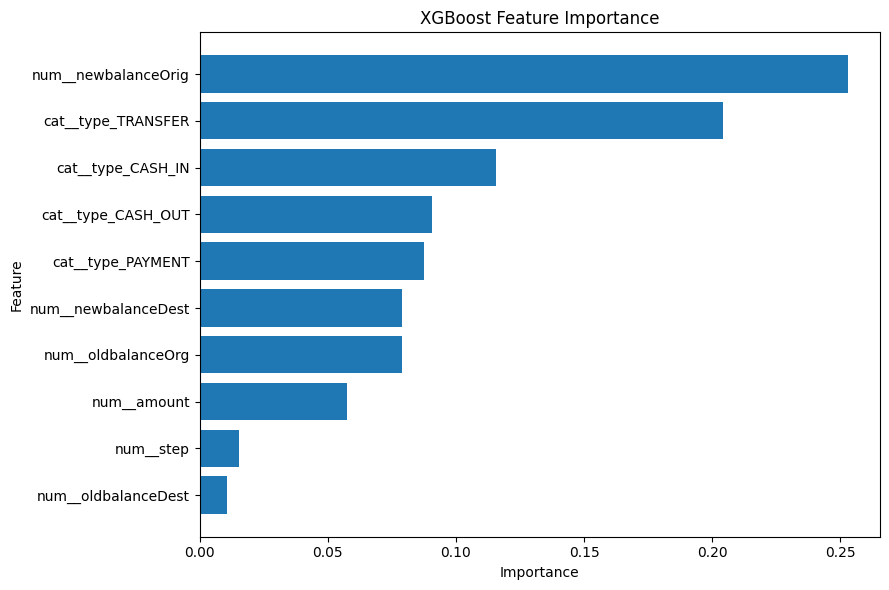

In [55]:
plt.figure(figsize=(9, 6))

top_features = feature_importance_xgb.head(10)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

## ROC and precision-recall curves

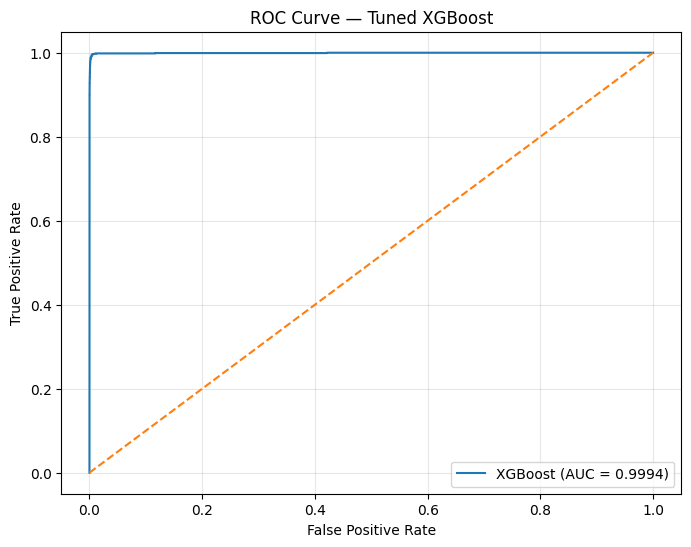

In [56]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(
    y_val,
    y_prob_tuned
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {tuned_roc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned XGBoost")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

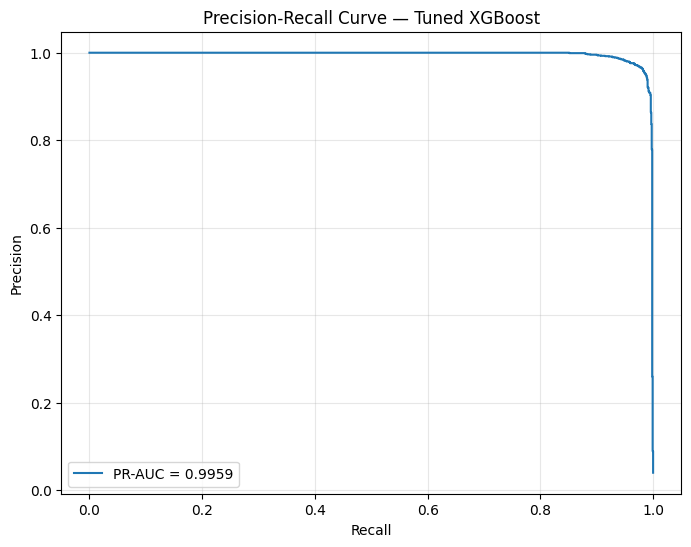

In [57]:
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(
    y_val,
    y_prob_tuned
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {tuned_pr:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Tuned XGBoost")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Choosing the threshold

Using the threshold table on the validation set from earlier, the highest threshold
that still keeps recall at 95% or above is chosen. The goal is to catch almost all fraud, but with as few
false alarms as possible.

The threshold is chosen only on the validation set, and then used once on the realistic test set below.

In [58]:
# Highest threshold that keeps validation recall at 95% or above
recall_rule_threshold = round(
    threshold_df.loc[threshold_df["Recall"] >= 0.95, "Threshold"].max(),
    2
)

print("Threshold chosen on validation set (recall rule):", recall_rule_threshold)

Threshold chosen on validation set (recall rule): 0.6


FINAL OPERATING THRESHOLD: 0.6


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953199
           1       0.65      0.96      0.78      1232

    accuracy                           1.00    954431
   macro avg       0.83      0.98      0.89    954431
weighted avg       1.00      1.00      1.00    954431


Confusion Matrix:
[[952577    622]
 [    53   1179]]


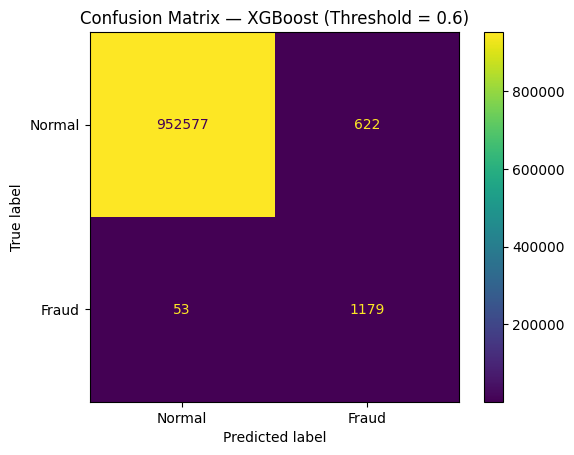

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

# Threshold chosen on the validation set (recall rule)
final_threshold = recall_rule_threshold

y_realistic_final_pred = (
    y_realistic_prob >= final_threshold
).astype(int)

print("FINAL OPERATING THRESHOLD:", final_threshold)

print(
    classification_report(
        y_realistic,
        y_realistic_final_pred
    )
)

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_realistic,
    y_realistic_final_pred
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
).plot()

plt.title(
    f"Confusion Matrix — XGBoost (Threshold = {final_threshold})"
)

plt.show()

## Summary of all models

In [61]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Precision": [
        0.45,
        0.88,
        0.83,
        0.97,
        0.98,
        0.98
    ],
    "Recall": [
        0.98,
        0.98,
        0.98,
        0.89,
        0.97,
        0.96
    ],
    "F1": [
        0.62,
        0.93,
        0.90,
        0.93,
        0.97,
        0.97
    ],
    "ROC_AUC": [
        0.9933,
        0.9884,
        0.9986,
        0.9979,
        0.9994,
        0.9994
    ],
    "PR_AUC": [
        0.9080,
        0.9580,
        0.9889,
        0.9822,
        0.9961,
        0.9959
    ]
})

display(final_results)

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.45,0.98,0.62,0.9933,0.9080
1,Decision Tree,0.88,0.98,0.93,0.9884,0.9580
2,Random Forest,0.83,0.98,0.90,0.9986,0.9889
3,Gradient Boosting,0.97,0.89,0.93,0.9979,0.9822
4,XGBoost,0.98,0.97,0.97,0.9994,0.9961
5,Tuned XGBoost,0.98,0.96,0.97,0.9994,0.9959


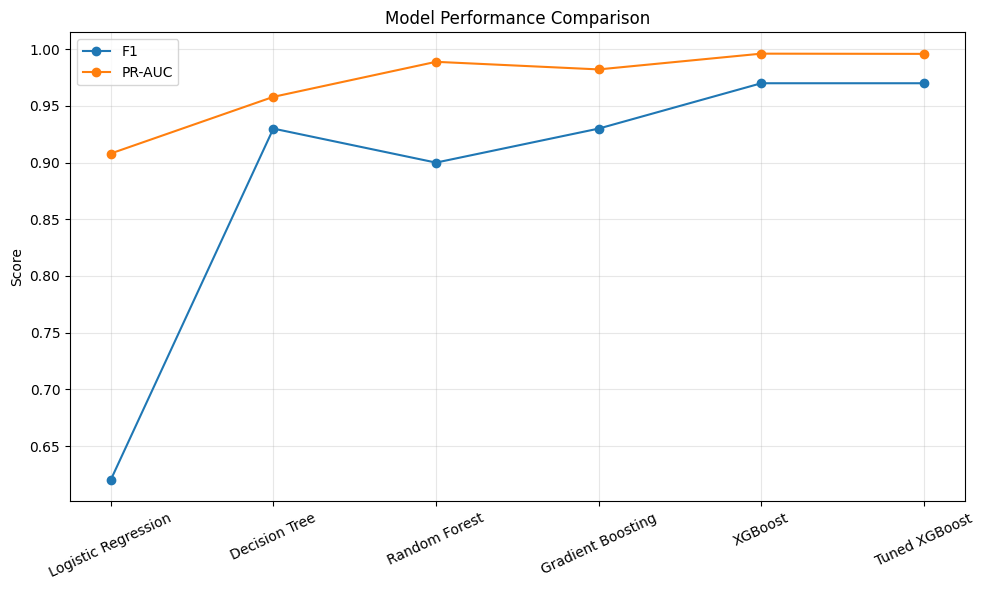

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    final_results["Model"],
    final_results["F1"],
    marker="o",
    label="F1"
)

plt.plot(
    final_results["Model"],
    final_results["PR_AUC"],
    marker="o",
    label="PR-AUC"
)

plt.xticks(rotation=25)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP

SHAP is used to understand what the model is actually using to make predictions.
It shows how much each feature contributed to a prediction and whether it pushed it
towards fraud or towards normal.

It is computed on all the fraud cases from the realistic test set plus 5,000 normal transactions.

In [62]:
import shap

os.makedirs("images", exist_ok=True)

xgb_pre = best_xgb.named_steps["preprocessor"]
xgb_clf = best_xgb.named_steps["classifier"]

# Sample: all fraud + 5,000 normal transactions from the realistic test set
shap_sample = pd.concat([
    realistic_test[realistic_test["isFraud"] == 1],
    realistic_test[realistic_test["isFraud"] == 0].sample(
        n=5000,
        random_state=42
    )
]).reset_index(drop=True)

X_shap = xgb_pre.transform(shap_sample[original_features])

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_shap)

# Readable feature names ("num__amount" -> "amount")
shap_values.feature_names = [
    name.split("__", 1)[1]
    for name in xgb_pre.get_feature_names_out()
]

# Show original (unscaled) amounts and balances in the plots
n_num = len(numerical_original)
shap_values.data = np.hstack([
    shap_sample[numerical_original].to_numpy(dtype=float),
    X_shap[:, n_num:]
])

### Average feature impact

Average contribution of each feature. Longer bar = more important.

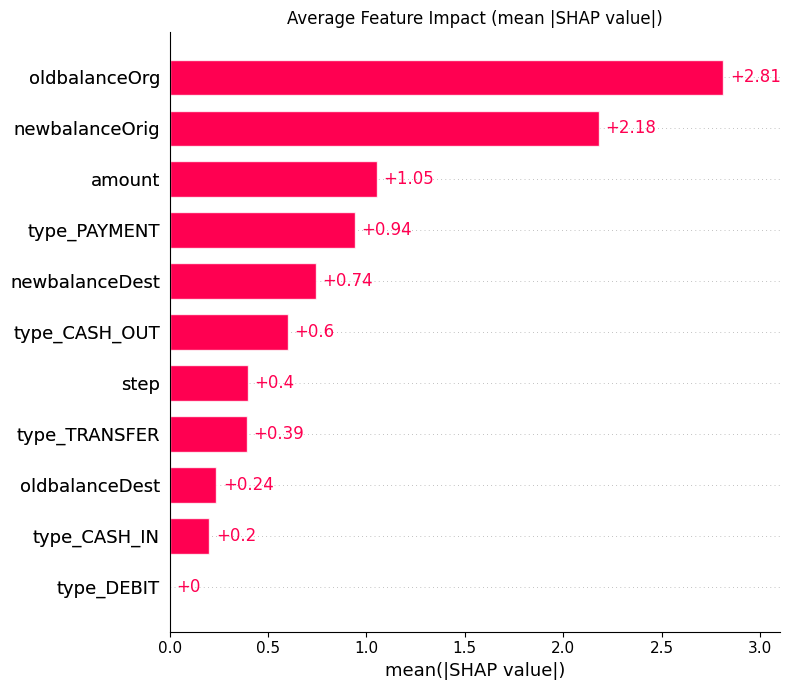

In [63]:
plt.figure()
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title("Average Feature Impact (mean |SHAP value|)")
plt.tight_layout()
plt.savefig("images/shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Summary plot

Each dot is one transaction. Right side = pushed towards fraud, left side = pushed towards normal.
Red means a high value of that feature and blue means a low value.

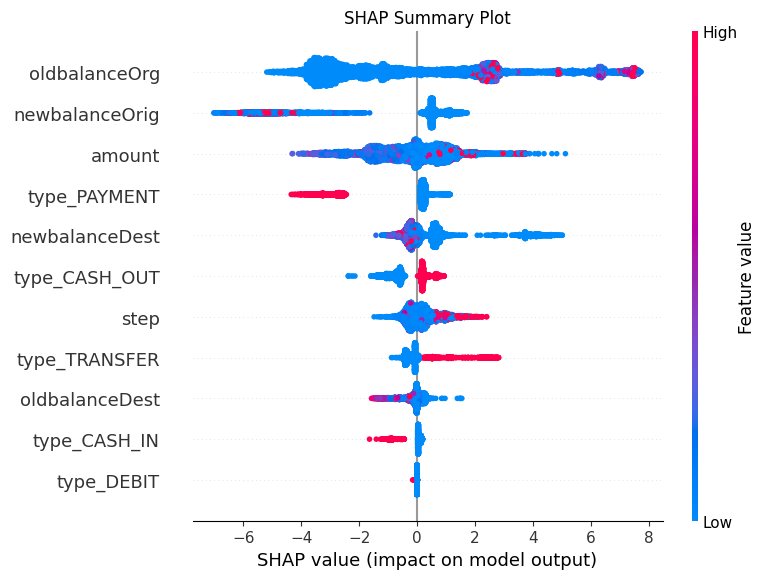

In [64]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("images/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

### Looking at one fraud transaction

This takes the fraud case the model was most confident about and shows which features caused
the prediction. Red bars push towards fraud, blue bars push towards normal.

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
143,59,TRANSFER,3904257.51,3904257.51,0.0,0.0,0.0


Predicted fraud probability: 0.9999


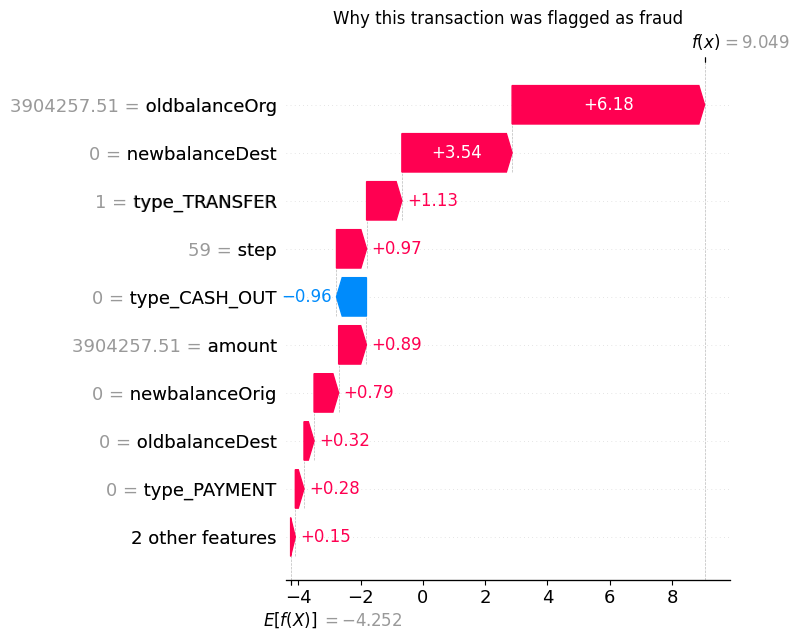

In [65]:
shap_prob = xgb_clf.predict_proba(X_shap)[:, 1]

# Fraud transaction with the highest predicted fraud probability
fraud_idx = np.where(shap_sample["isFraud"] == 1)[0]
example = fraud_idx[np.argmax(shap_prob[fraud_idx])]

display(shap_sample.loc[[example], original_features])
print(f"Predicted fraud probability: {shap_prob[example]:.4f}")

plt.figure()
shap.plots.waterfall(shap_values[example], max_display=10, show=False)
plt.title("Why this transaction was flagged as fraud")
plt.tight_layout()
plt.savefig("images/shap_example.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

- XGBoost performed best out of the five models, and tuning it with Optuna didn't change the results much.
- Using the recall rule on the validation set gave a threshold of 0.60.
- On the realistic test set (0.129% fraud) the model got:
  - Precision: 65.46%
  - Recall: 95.70%
  - F1-score: 77.74%
  - ROC-AUC: 0.9996
  - PR-AUC: 0.9640
- It caught 1,179 of the 1,232 frauds, with 622 false alarms out of 953,199 normal transactions.
- SHAP shows the model mostly relies on the origin account balances. A large account that gets
  emptied to 0 is the strongest sign of fraud.

The precision on the realistic test set is a lot lower than on the validation set, because there are
far more normal transactions in real data. This is why it was important to test with the real fraud rate.